In [7]:
import numpy as np
import matplotlib.pyplot as plt

# House sizes (sq ft)
X = np.array([800, 1100, 1300, 1500, 1700, 1900, 2100, 2300, 2500, 2800])

# Prices ($k)
y = np.array([150, 195, 210, 260, 295, 320, 355, 370, 410, 460])

X = X / 1000  
y = y / 100 

In [8]:
def predict(x,w,b):
    return w * x + b


predictions = predict(X, w=0.15, b=50)
print(predictions)
np.mean(predictions)
np.sum(predictions)

def mse(y_true,y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true,y_pred):
    return np.abs(y_true - y_pred).mean()

def compute_gradient(X,y,w,b):
    N = len(X)
    y_pred = predict(X,w,b)
    dw = np.mean(-2 * X * (y - y_pred))
    db = np.mean(-2 * (y - y_pred))
    return dw, db

[50.12  50.165 50.195 50.225 50.255 50.285 50.315 50.345 50.375 50.42 ]


In [9]:
w = 0.0
b = 0.0
learning_rate = 0.01
epochs = 200
loss_history = []

for epoch in range(epochs):
    predictions = predict(X, w, b)
    dw, db = compute_gradient(X, y, w, b)
    w -= learning_rate * dw
    b -= learning_rate * db
    current_mse = mse(y, predictions)
    loss_history.append(current_mse)
    if epoch % 20 == 0:
     print(f"Epoch {epoch}  →  w={w:.4f}  b={b:.4f}  MSE={current_mse:.1f}")

Epoch 0  →  w=0.1203  b=0.0605  MSE=10.0
Epoch 20  →  w=1.1521  b=0.5691  MSE=0.2
Epoch 40  →  w=1.3127  b=0.6336  MSE=0.0
Epoch 60  →  w=1.3425  b=0.6320  MSE=0.0
Epoch 80  →  w=1.3526  b=0.6208  MSE=0.0
Epoch 100  →  w=1.3595  b=0.6085  MSE=0.0
Epoch 120  →  w=1.3657  b=0.5964  MSE=0.0
Epoch 140  →  w=1.3718  b=0.5847  MSE=0.0
Epoch 160  →  w=1.3776  b=0.5733  MSE=0.0
Epoch 180  →  w=1.3832  b=0.5623  MSE=0.0


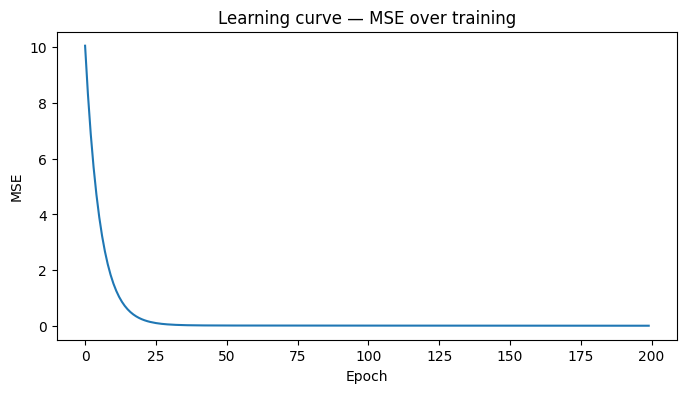

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(range(epochs), loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Learning curve — MSE over training')
plt.show()

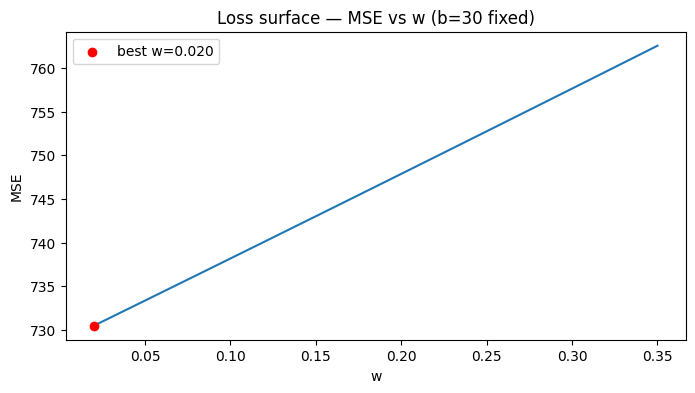

Best w found: 0.0200  →  MSE=730.5


In [11]:
w_values = np.linspace(0.02, 0.35, 100)

# compute mse for each w (b fixed at 30)
mse_values = [mse(y, predict(X, w, 30)) for w in w_values]

# find the best w
best_w = w_values[np.argmin(mse_values)]
best_mse = min(mse_values)

plt.figure(figsize=(8, 4))
# your plot here — line for mse_values, mark best_w with a dot
plt.xlabel('w')
plt.ylabel('MSE')
plt.title('Loss surface — MSE vs w (b=30 fixed)')
plt.plot(w_values, mse_values)
plt.scatter([best_w], [best_mse], color='red', zorder=5, label=f'best w={best_w:.3f}')
plt.legend()
plt.show()

print(f"Best w found: {best_w:.4f}  →  MSE={best_mse:.1f}")